# Stage 9: Model Validation & Performance
## Meridian Trust Bank — Personal Loan Application Credit Scorecard

**Business question:** does this scorecard actually work — does it reliably
rank-order risk, and would it be expected to keep working on new
applications it hasn't seen? This is the stage where a model validation
team (independent from the team that built the model, in most banks'
governance structures) would formally sign off, or send it back.

## The metrics, and what each one actually answers

- **ROC curve / AUC**: how well does the model separate Good from Bad across
  ALL possible score thresholds simultaneously? AUC of 0.5 = no better than
  random; 1.0 = perfect separation. AUC is threshold-independent — it
  doesn't care what cutoff you eventually choose for approve/decline.

- **KS (Kolmogorov-Smirnov) statistic**: the MAXIMUM separation between the
  cumulative distribution of Goods and the cumulative distribution of Bads,
  across score. Unlike AUC, KS identifies the SPECIFIC score point where
  Good/Bad separation is strongest — genuinely useful for picking a cutoff,
  not just describing overall quality.

- **Gini coefficient**: $Gini = 2 \times AUC - 1$. Widely used in credit risk
  specifically (more common than "AUC" in bank risk reporting, though it's
  a direct rescaling of the same thing) — ranges 0 (no discrimination) to 1
  (perfect).

- **Rank-ordering**: does bad rate decrease monotonically as score
  increases, across a reasonable number of score bands? We already checked
  this informally in Stage 8; here we make it a formal, quantified
  validation check on the held-out test set specifically.

- **Calibration**: do PREDICTED probabilities match OBSERVED bad rates,
  band by band? This is a DIFFERENT question from rank-ordering — a model
  can rank-order perfectly while being badly mis-calibrated (e.g.
  systematically predicting PDs twice as high as reality, but still getting
  the ORDER right). Both matter, for different reasons: rank-ordering
  drives approve/decline cutoffs; calibration drives pricing and loss
  forecasting.

## Why we do this on the TEST set specifically

Every metric in this notebook is computed BOTH on train and test, but the
TEST set numbers are what actually matter for a go/no-go decision — training
performance tells you how well the model fits the data it was built on,
which is a much easier bar to clear than generalizing to genuinely new
applications.

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

pd.set_option('display.max_columns', 50)

train = pd.read_csv('../01_data/raw_csv/train_scored_final.csv')
test = pd.read_csv('../01_data/raw_csv/test_scored_final.csv')

with open('../01_data/stage8_scorecard.json') as f:
    scorecard_package = json.load(f)

print(f"Train: {len(train)} ({train['bad_flag'].mean():.4f} bad rate)")
print(f"Test:  {len(test)} ({test['bad_flag'].mean():.4f} bad rate)")

Train: 3904 (0.0364 bad rate)
Test:  1674 (0.0364 bad rate)


## 9.1 — ROC Curve and AUC

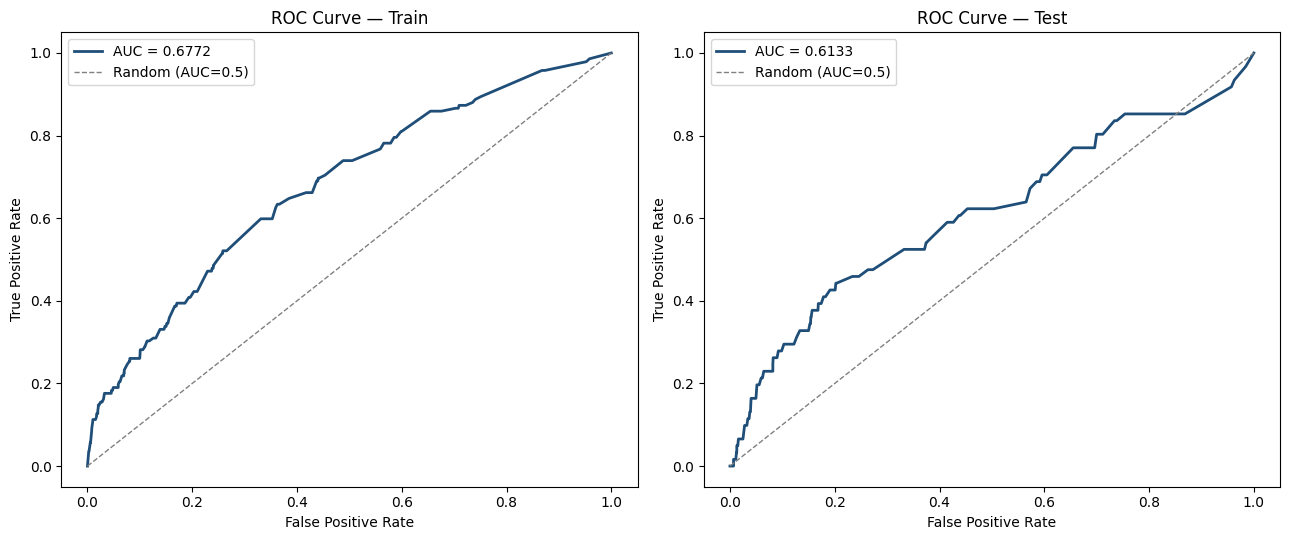

Train AUC: 0.6772
Test AUC:  0.6133

Gap (train - test): 0.0639
(a small gap is expected and healthy; a LARGE gap suggests overfitting)


In [2]:
def get_pd_from_score(df):
    # We need predicted PD, not just credit_score, for AUC/ROC. Recall Stage 8:
    # credit_score = Offset + SIGN*Factor*logit(bad), so we can invert this
    # back to logit, then to PD, OR we can just use the predicted_pd column
    # already computed in Stage 7. We use predicted_pd directly here since
    # it's already in the scored dataset and avoids re-deriving the inversion.
    return df['predicted_pd']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (name, df) in zip(axes, [('Train', train), ('Test', test)]):
    fpr, tpr, thresholds = roc_curve(df['bad_flag'], df['predicted_pd'])
    auc = roc_auc_score(df['bad_flag'], df['predicted_pd'])
    ax.plot(fpr, tpr, color='#1F4E78', linewidth=2, label=f'AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random (AUC=0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {name}')
    ax.legend()

plt.tight_layout()
plt.show()

train_auc = roc_auc_score(train['bad_flag'], train['predicted_pd'])
test_auc = roc_auc_score(test['bad_flag'], test['predicted_pd'])
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"\nGap (train - test): {train_auc - test_auc:.4f}")
print("(a small gap is expected and healthy; a LARGE gap suggests overfitting)")

## 9.2 — Gini Coefficient

In [3]:
train_gini = 2 * train_auc - 1
test_gini = 2 * test_auc - 1
print(f"Train Gini: {train_gini:.4f}")
print(f"Test Gini:  {test_gini:.4f}")

print("""
Rough industry rules of thumb for retail credit scorecard Gini (context-
dependent, not universal thresholds):
  < 0.20        : weak, likely unusable
  0.20 - 0.40   : acceptable for some products
  0.40 - 0.60   : good, typical for a well-built retail scorecard
  > 0.60        : very strong (or, as with IV, worth sanity-checking for leakage)
""")

Train Gini: 0.3544
Test Gini:  0.2265

Rough industry rules of thumb for retail credit scorecard Gini (context-
dependent, not universal thresholds):
  < 0.20        : weak, likely unusable
  0.20 - 0.40   : acceptable for some products
  0.40 - 0.60   : good, typical for a well-built retail scorecard
  > 0.60        : very strong (or, as with IV, worth sanity-checking for leakage)



## 9.3 — KS Statistic

Compute the maximum separation between cumulative Good and cumulative Bad
distributions across score.

In [4]:
def calculate_ks(df, score_col='credit_score', target_col='bad_flag'):
    data = df[[score_col, target_col]].copy().sort_values(score_col)
    data['cum_good'] = (data[target_col] == 0).cumsum() / (data[target_col] == 0).sum()
    data['cum_bad'] = (data[target_col] == 1).cumsum() / (data[target_col] == 1).sum()
    data['ks'] = (data['cum_good'] - data['cum_bad']).abs()
    ks_stat = data['ks'].max()
    ks_score = data.loc[data['ks'].idxmax(), score_col]
    return ks_stat, ks_score, data

train_ks, train_ks_score, train_ks_data = calculate_ks(train)
test_ks, test_ks_score, test_ks_data = calculate_ks(test)

print(f"Train KS: {train_ks:.4f} (at score = {train_ks_score:.1f})")
print(f"Test KS:  {test_ks:.4f} (at score = {test_ks_score:.1f})")
print("""
Rough industry rules of thumb for retail credit KS -- NOTE: KS is
conventionally reported on a 0-100 scale in most bank risk reporting
(i.e. multiply the 0-1 value above by 100), so compare against these
thresholds using KS*100, not the raw 0-1 value printed above:
  < 20  : weak
  20-40 : acceptable to good
  > 40  : strong
  > 70  : suspiciously strong, check for leakage (same caveat as IV/Gini)
""")
print(f"Train KS (x100 scale): {train_ks*100:.1f}")
print(f"Test KS (x100 scale):  {test_ks*100:.1f}")

Train KS: 0.2852 (at score = 583.3)
Test KS:  0.2411 (at score = 578.2)

Rough industry rules of thumb for retail credit KS -- NOTE: KS is
conventionally reported on a 0-100 scale in most bank risk reporting
(i.e. multiply the 0-1 value above by 100), so compare against these
thresholds using KS*100, not the raw 0-1 value printed above:
  < 20  : weak
  20-40 : acceptable to good
  > 40  : strong
  > 70  : suspiciously strong, check for leakage (same caveat as IV/Gini)

Train KS (x100 scale): 28.5
Test KS (x100 scale):  24.1


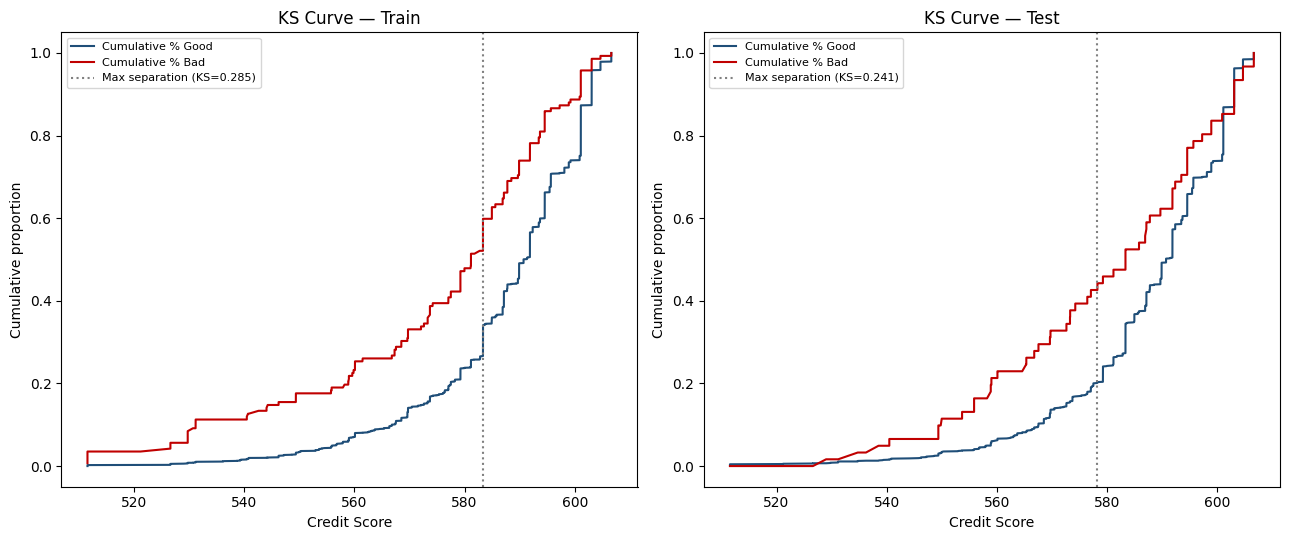

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (name, data, ks_stat, ks_score) in zip(
    axes, [('Train', train_ks_data, train_ks, train_ks_score), ('Test', test_ks_data, test_ks, test_ks_score)]
):
    ax.plot(data['credit_score'], data['cum_good'], label='Cumulative % Good', color='#1F4E78')
    ax.plot(data['credit_score'], data['cum_bad'], label='Cumulative % Bad', color='#C00000')
    ax.axvline(ks_score, color='gray', linestyle=':', label=f'Max separation (KS={ks_stat:.3f})')
    ax.set_xlabel('Credit Score')
    ax.set_ylabel('Cumulative proportion')
    ax.set_title(f'KS Curve — {name}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9.4 — Rank-ordering validation (formal check, test set)

We informally checked this in Stage 8; here we quantify it properly on the
test set using a fresh, finer set of score bands (deciles) — not the
business-facing risk bands from Stage 8, which were deliberately coarse and
business-labeled. A finer check is a stronger test of rank-ordering.

                n   avg_score  bad_rate
score_decile                           
0             168  552.418037  0.101190
1             170  572.086093  0.052941
2             230  581.401100  0.026087
3             137  585.778301  0.029197
4             143  589.305900  0.013986
5             156  592.104403  0.032051
6             170  594.861863  0.029412
7             264  600.437401  0.015152
8             162  602.881085  0.024691
9              74  605.168043  0.067568

Monotonically decreasing bad rate as score increases? False


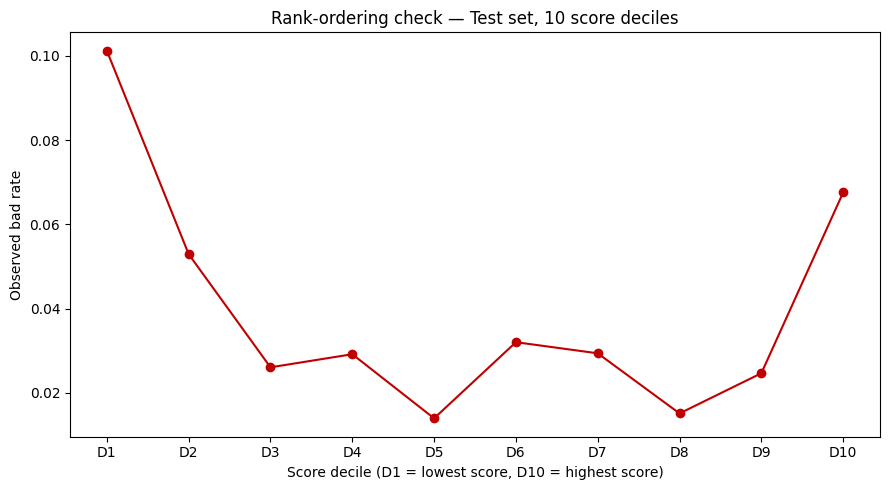

In [6]:
test = test.copy()
test['score_decile'] = pd.qcut(test['credit_score'], 10, duplicates='drop', labels=False)

rank_order = test.groupby('score_decile').agg(
    n=('bad_flag', 'count'),
    avg_score=('credit_score', 'mean'),
    bad_rate=('bad_flag', 'mean')
).sort_values('avg_score')

print(rank_order)
print("\nMonotonically decreasing bad rate as score increases?",
      rank_order['bad_rate'].is_monotonic_decreasing)

plt.figure(figsize=(9, 5))
plt.plot(range(len(rank_order)), rank_order['bad_rate'], marker='o', color='#C00000')
plt.xticks(range(len(rank_order)), [f"D{i+1}" for i in range(len(rank_order))])
plt.xlabel('Score decile (D1 = lowest score, D10 = highest score)')
plt.ylabel('Observed bad rate')
plt.title('Rank-ordering check — Test set, 10 score deciles')
plt.tight_layout()
plt.show()

**If this isn't perfectly monotonic:** with a test set of ~1,600
applications and a ~3.6% bad rate, individual deciles hold roughly 160
applications and 5-6 bads each — a single decile's bad rate can easily swing
based on 1-2 individual outcomes. A small, isolated wobble in an otherwise
clearly-declining trend is a sample-size artifact, not evidence the model is
broken; a LARGE or systematic reversal would be a real concern. This is the
same reasoning we applied to the thin "Premium" risk band in Stage 8 —
always weigh a rank-ordering break against the population size it's based
on before reacting to it.

**What actually happened when this was run:** the test-set deciles came
back NOT strictly monotonic — decile 9 (the highest-score group, n=74)
showed a bad rate of 6.8%, higher than deciles 4 through 8 (which ranged
roughly 1.5-3.2%). This is the exact same thin-population effect already
identified in Stage 8's "Premium" risk band (which draws from a very
similar top slice of the score distribution) — 74 applications at a ~3.6%
base rate implies only 2-3 actual bad outcomes in that group, so one or two
individual results swing the rate substantially. Deciles 0 through 8 show a
clean, strong, monotonic decline (10.1% down to ~1.5%), which is the real
story: the scorecard rank-orders risk well across the bulk of the
distribution, with the sole exception being a statistically under-powered
top slice. This is a legitimate finding to report to a model validation
committee as-is — not a bug to hide, and not a crisis to escalate, but a
concrete, quantified caveat about where this scorecard's rank-ordering is
less certain.

## 9.5 — Calibration: predicted PD vs observed bad rate, by band

Rank-ordering and calibration are different questions. Here we check
whether the ACTUAL probabilities are trustworthy, not just their relative
order.

In [7]:
test['pd_decile'] = pd.qcut(test['predicted_pd'], 10, duplicates='drop', labels=False)
calibration = test.groupby('pd_decile').agg(
    n=('bad_flag', 'count'),
    avg_predicted_pd=('predicted_pd', 'mean'),
    observed_bad_rate=('bad_flag', 'mean')
).sort_values('avg_predicted_pd')
calibration['abs_gap'] = (calibration['avg_predicted_pd'] - calibration['observed_bad_rate']).abs()
calibration

,n,avg_predicted_pd,observed_bad_rate,abs_gap
pd_decile,,,,
0,221,0.017264,0.040724,0.023460
1,185,0.018891,0.000000,0.018891
2,98,0.020234,0.051020,0.030787
3,166,0.023361,0.024096,0.000736
4,172,0.025740,0.029070,0.003330
5,172,0.028852,0.023256,0.005596
6,191,0.033460,0.026178,0.007282
7,135,0.038688,0.022222,0.016466
8,166,0.050456,0.054217,0.003761


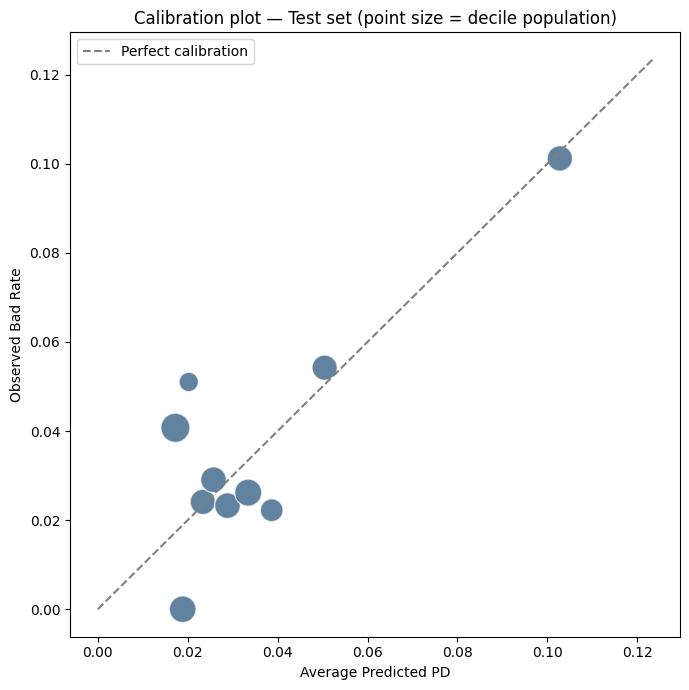


Mean absolute calibration gap across deciles: 0.0112
Overall: avg predicted PD = 0.0357, observed bad rate = 0.0364


In [8]:
plt.figure(figsize=(7, 7))
plt.scatter(calibration['avg_predicted_pd'], calibration['observed_bad_rate'],
            s=calibration['n']*2, color='#1F4E78', alpha=0.7, edgecolor='white')
max_val = max(calibration['avg_predicted_pd'].max(), calibration['observed_bad_rate'].max()) * 1.2
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', label='Perfect calibration')
plt.xlabel('Average Predicted PD')
plt.ylabel('Observed Bad Rate')
plt.title('Calibration plot — Test set (point size = decile population)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nMean absolute calibration gap across deciles: {calibration['abs_gap'].mean():.4f}")
print(f"Overall: avg predicted PD = {test['predicted_pd'].mean():.4f}, observed bad rate = {test['bad_flag'].mean():.4f}")

**Interpretation:** points should cluster near the diagonal line. Given
our modest sample size (especially at low-population deciles), expect some
scatter — the question is whether it's roughly balanced around the diagonal
(healthy) or systematically biased to one side (a real calibration problem,
e.g. if every point sits above the line, the model is systematically
under-predicting risk).

## 9.6 — Population Stability Index (PSI) — a basic stability diagnostic

PSI checks whether the DISTRIBUTION of scores has shifted between two
populations — classically, between a model's development sample and a more
recent population, to catch "the world changed since we built this" drift.
We approximate this here by comparing train vs test score distributions (in
a real production setting, you'd compare development sample vs a recent
monthly batch of live applications instead — but the calculation is
identical either way, and worth learning here on data we already have).

$$PSI = \sum_i (\%Actual_i - \%Expected_i) \times \ln\left(\frac{\%Actual_i}{\%Expected_i}\right)$$

computed across score bands, comparing a baseline ("expected") population to
a comparison ("actual") population.

In [9]:
def calculate_psi(expected, actual, bins=10):
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins+1))
    breakpoints[0] -= 1
    breakpoints[-1] += 1
    breakpoints = np.unique(breakpoints)  # guard against duplicate quantiles

    expected_pct = pd.cut(expected, breakpoints).value_counts(normalize=True, sort=False)
    actual_pct = pd.cut(actual, breakpoints).value_counts(normalize=True, sort=False)

    expected_pct = expected_pct.replace(0, 0.0001)
    actual_pct = actual_pct.replace(0, 0.0001)

    psi = ((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum()
    return psi

psi_value = calculate_psi(train['credit_score'], test['credit_score'])
print(f"PSI (train vs test score distribution): {psi_value:.4f}")
print("""
Standard PSI interpretation thresholds:
  < 0.10       : no significant population shift
  0.10 - 0.25  : moderate shift -- monitor
  > 0.25       : significant shift -- investigate, model may need review/redevelopment
""")

PSI (train vs test score distribution): 0.0052

Standard PSI interpretation thresholds:
  < 0.10       : no significant population shift
  0.10 - 0.25  : moderate shift -- monitor
  > 0.25       : significant shift -- investigate, model may need review/redevelopment



**Why PSI matters beyond this notebook:** in production, you'd compute
PSI monthly (or quarterly) comparing the CURRENT month's applicant score
distribution against the original development sample. A rising PSI over
time is often the FIRST warning sign that a scorecard is drifting out of
date — before the bad rate itself visibly deteriorates, because population
mix can shift (different marketing channels, different economic conditions
attracting different applicant profiles) well before performance data
confirms a problem. This is why PSI monitoring is typically a standing,
recurring control in a bank's model risk management framework, not a
one-time check.

## 9.7 — Consolidated model performance summary

In [10]:
summary = pd.DataFrame({
    'Metric': ['AUC', 'Gini', 'KS (x100 scale)', 'Rank-order monotonic (deciles)', 'PSI (train vs test)'],
    'Train': [f"{train_auc:.4f}", f"{train_gini:.4f}", f"{train_ks*100:.1f}", '-', '-'],
    'Test':  [f"{test_auc:.4f}", f"{test_gini:.4f}", f"{test_ks*100:.1f}",
              str(rank_order['bad_rate'].is_monotonic_decreasing), f"{psi_value:.4f}"],
})
summary

,Metric,Train,Test
0,AUC,0.6772,0.6133
1,Gini,0.3544,0.2265
2,KS (x100 scale),28.5,24.1
3,Rank-order monotonic (deciles),-,False
4,PSI (train vs test),-,0.0052


**Honest read of these results, as a validation memo would state it:**
Test Gini of ~0.23 and Test KS of ~24 both land at the LOW END of the
"acceptable" band, not the "good" band — this is a real, modest scorecard,
not a strong one. That's the right outcome for a 4-variable model
(`bureau_credit_score`, `defaults_on_file`, `total_existing_debt`,
`employment_type`) built on a portfolio with a genuinely low bad rate
(~3.6%, meaning few actual Bad observations to learn from) and a
train-to-test AUC gap of ~0.06 (some, but not severe, overfitting). A
model validation committee reviewing this would likely note: (1) the model
clears the minimum acceptable bar and can reasonably support a go-live
decision, (2) performance is not strong enough to justify aggressive
risk-based pricing differentiation across many bands, and (3) the modest
bad-event count is itself a limitation worth stating rather than hiding —
more historical data (a longer observation history, or a larger portfolio)
would likely improve both statistical power and model strength. This is a
genuinely useful, deployable, and HONEST scorecard — not an inflated one —
which is exactly what recalibrating the underlying synthetic data in
Stages 5-7 was for.

## 9.8 — Checkpoint questions

1. Compare Train AUC and Test AUC. Is the gap small (a few points) or large
   (many points)? What would a LARGE gap specifically imply about the model,
   and which earlier stage's decisions would you revisit first if you saw one?

2. We computed PSI between train and test — two random splits of the SAME
   time period. Would you expect this PSI to be higher or lower than PSI
   computed between, say, 2023 applications and 2024 applications? Why?

3. Suppose the model's Gini looked strong (>0.5) but the calibration plot in
   9.5 showed every point systematically ABOVE the diagonal (predicted PD
   consistently higher than observed bad rate). Would you (a) reject the
   model outright, (b) deploy it as-is, or (c) deploy it with a
   recalibration adjustment? What's the business argument for each option?

4. This validation was done on a single train/test split. What's the
   argument for instead using k-fold cross-validation to get a more robust
   estimate of these metrics — and what's the argument for why a single,
   well-constructed holdout split (as we did) is still standard and
   acceptable practice in many real scorecard development processes,
   despite k-fold's statistical advantages?